<a href="https://colab.research.google.com/github/Lambertlan123/stock-prediction/blob/main/NVIDIA_Corp_Stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf

# Download historical data for NVIDIA Corp
stock_data = yf.download('NVDA', start='2020-01-01', end='2025-02-10')

# Save it to a CSV file
stock_data.to_csv('NVDA_data.csv')

[*********************100%***********************]  1 of 1 completed


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Step 1: Load the historical stock data
data = pd.read_csv('NVDA_data.csv')

In [ ]:
data# Check the first few rows

,Price,Close,High,Low,Open,Volume
0,Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,5.972711086273193,5.972711086273193,5.893294431508401,5.9438323458902245,237536000
3,2020-01-03,5.877111434936523,5.920927891690787,5.828066918698495,5.852962643555382,205384000
4,2020-01-06,5.901757717132568,5.906985776484988,5.757612380789321,5.783752677551418,262636000
...,...,...,...,...,...,...
1280,2025-02-03,116.66000366210938,118.56999969482422,113.01000213623047,114.75,371235700
1281,2025-02-04,118.6500015258789,121.19999694824219,116.69999694824219,116.95999908447266,256550000
1282,2025-02-05,124.83000183105469,125.0,120.76000213623047,121.76000213623047,262230800
1283,2025-02-06,128.67999267578125,128.77000427246094,125.20999908447266,127.41999816894531,251483600


In [ ]:
data = data.iloc[2:].reset_index(drop=True)  # Drop first two rows, reset index
data

,Price,Close,High,Low,Open,Volume
0,2020-01-02,5.972711086273193,5.972711086273193,5.893294431508401,5.9438323458902245,237536000
1,2020-01-03,5.877111434936523,5.920927891690787,5.828066918698495,5.852962643555382,205384000
2,2020-01-06,5.901757717132568,5.906985776484988,5.757612380789321,5.783752677551418,262636000
3,2020-01-07,5.973208904266357,6.019016870261898,5.885078345508204,5.930139377975761,314856000
4,2020-01-08,5.98441219329834,6.025739034600884,5.928895038944445,5.968976832702461,277108000
...,...,...,...,...,...,...
1278,2025-02-03,116.66000366210938,118.56999969482422,113.01000213623047,114.75,371235700
1279,2025-02-04,118.6500015258789,121.19999694824219,116.69999694824219,116.95999908447266,256550000
1280,2025-02-05,124.83000183105469,125.0,120.76000213623047,121.76000213623047,262230800
1281,2025-02-06,128.67999267578125,128.77000427246094,125.20999908447266,127.41999816894531,251483600


In [ ]:
data.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [ ]:
# Rename the 'Price' column to 'Date'
data.rename(columns={'Price': 'Date'}, inplace=True)

# Convert 'Date' to datetime format
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Check the columns to ensure nothing was dropped
print(data.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [ ]:
data

,Date,Close,High,Low,Open,Volume
0,2020-01-02,5.972711086273193,5.972711086273193,5.893294431508401,5.9438323458902245,237536000
1,2020-01-03,5.877111434936523,5.920927891690787,5.828066918698495,5.852962643555382,205384000
2,2020-01-06,5.901757717132568,5.906985776484988,5.757612380789321,5.783752677551418,262636000
3,2020-01-07,5.973208904266357,6.019016870261898,5.885078345508204,5.930139377975761,314856000
4,2020-01-08,5.98441219329834,6.025739034600884,5.928895038944445,5.968976832702461,277108000
...,...,...,...,...,...,...
1278,2025-02-03,116.66000366210938,118.56999969482422,113.01000213623047,114.75,371235700
1279,2025-02-04,118.6500015258789,121.19999694824219,116.69999694824219,116.95999908447266,256550000
1280,2025-02-05,124.83000183105469,125.0,120.76000213623047,121.76000213623047,262230800
1281,2025-02-06,128.67999267578125,128.77000427246094,125.20999908447266,127.41999816894531,251483600


In [ ]:
# Keep only the 'Close' price column
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
prices = data['Close'].values
prices = prices.reshape(-1, 1)

# Step 2: Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(prices)

# Define training data length (80% of the data for training)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Step 3: Create the training datasets
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60  # Use 60 days of previous data to predict the next day
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [ ]:
# Reshape input to be [samples, time steps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Step 4: Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))  # Dropout to prevent overfitting
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 5: Train the model
model.fit(X_train, y_train, epochs=10, batch_size=64)

# Step 6: Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Reverse scaling

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0085
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0012
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 4.6312e-04
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 3.2286e-04
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 2.9757e-04
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 2.8747e-04
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 3.2282e-04
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 2.5219e-04
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 3.2694e-04
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 3.3813e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


In [ ]:
print(data.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


<ipython-input-28-d36899f7d769>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = np.nan
<ipython-input-28-d36899f7d769>:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single s

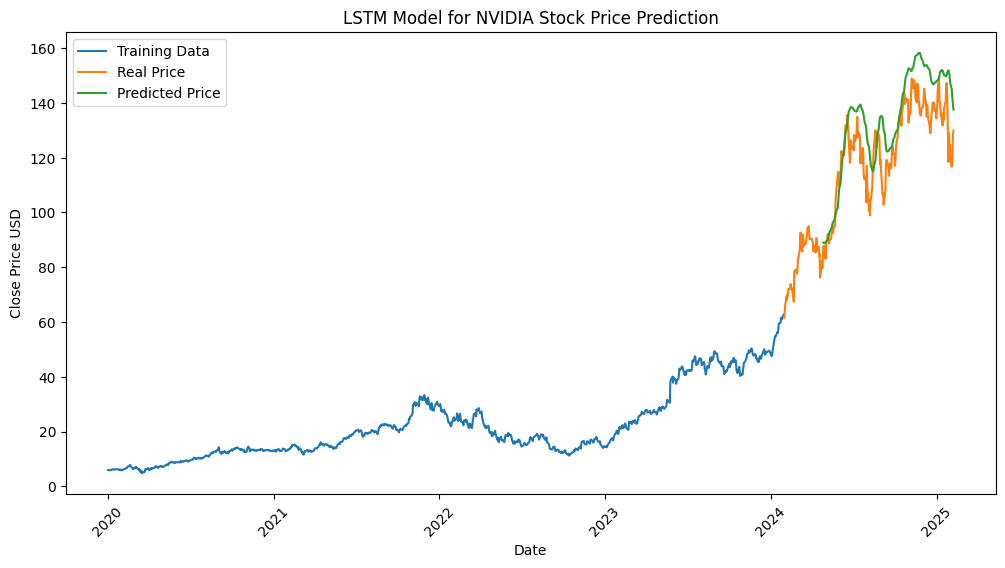

In [ ]:
####
# Convert 'Date' column to DateTime if it's not already
data['Date'] = pd.to_datetime(data['Date'])

# Set the 'Date' as the index of the DataFrame for easier plotting
data.set_index('Date', inplace=True)

# Adjust the train and valid DataFrames to include Date as the index
train = data[:train_size]
valid = data[train_size:]
valid['Predictions'] = np.nan

# Add the predictions
valid['Predictions'][-len(predictions):] = predictions.reshape(-1)

# Plotting the results with actual dates on the x-axis
plt.figure(figsize=(12,6))
plt.title('LSTM Model for NVIDIA Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Real Price')
plt.plot(valid['Predictions'], label='Predicted Price')
plt.legend(loc='upper left')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [ ]:
# Number of future days you want to predict
future_days = 20  # You can change this to however many days you want

# Get the last 60 days of data from the test set
last_sequence = scaled_data[-time_step:]  # Last 60 days (already scaled)

# Create an empty list to store future predictions
future_predictions = []

# Predict future prices
for _ in range(future_days):
    # Reshape the last sequence for prediction (LSTM expects input shape of (samples, time steps, features))
    last_sequence_reshaped = last_sequence.reshape((1, time_step, 1))

    # Predict the next day price
    predicted_price = model.predict(last_sequence_reshaped)

    # Append the prediction to future_predictions
    future_predictions.append(predicted_price[0, 0])

    # Update the last_sequence by appending the predicted price and removing the oldest data point
    last_sequence = np.append(last_sequence, predicted_price)[1:]  # Maintain 60 days sliding window

# Inverse transform the predicted future prices to get them back to the original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Plotting future predictions
import matplotlib.dates as mdates

# Extend the current valid set with future dates
future_dates = pd.date_range(data.index[-1], periods=future_days+1, freq='B')[1:]  # Business days only

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


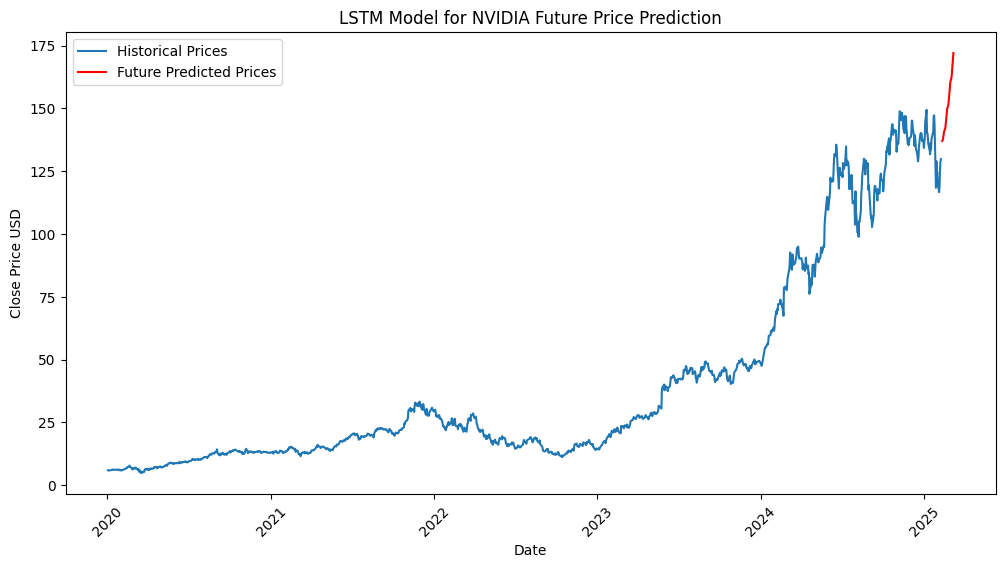

In [ ]:
# Plot historical data + future predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Historical Prices')
plt.plot(future_dates, future_predictions, label='Future Predicted Prices', color='r')
plt.title('LSTM Model for NVIDIA Future Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.show()